ACTION RECOGNITION WITH C2D AND LSTM

1. Important libraries

In [1]:
import os 
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import cv2
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.models import Sequential 
from keras.layers import Activation, Dense, Flatten
from keras.utils import plot_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import itertools
from tqdm import tqdm

- Import label file

In [2]:
label_data = pd.read_csv("/kaggle/input/ucf101/UCF101TrainTestSplits-RecognitionTask/ucfTrainTestlist/classInd.txt", sep=' ', header=None)
label_data.columns=['index', 'labels']
label_data = label_data.drop(['index'], axis=1)
label_data.head()

,labels
0,ApplyEyeMakeup
1,ApplyLipstick
2,Archery
3,BabyCrawling
4,BalanceBeam


In [3]:
len(label_data)

101

2. Prepare data

- Creates and returns paths to folders containing videos

In [4]:
def get_ucf101_paths():
    base_path = "/kaggle/input/ucf101/UCF101/UCF-101"
    paths = []
    for label in label_data.labels.values:
        paths.append(os.path.join(base_path, label))
    return paths

get_path = get_ucf101_paths()
print(get_path[3])

/kaggle/input/ucf101/UCF101/UCF-101/BabyCrawling


In [5]:
img_size = 64
frame_len = 5
NUM_CLASSES = 20

- Extract frames from video

In [6]:
def video_Frames(clip_path):
    video = cv2.VideoCapture(clip_path)
    frame_count = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
    for count in range(frame_len):
        video.set(cv2.CAP_PROP_POS_FRAMES,count*max(int(frame_count/frame_len),1))
        flag, frame = video.read()
        if not flag:
            break
        frame = cv2.resize(frame,(img_size,img_size))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) 
        #normalizing the pixels between 0 and 1
        frame = frame/255.0
        yield frame 
    video.release()
    
def load_video(dataset):
    imgs = []
    labels = []
    idx = 0
    for path_names in dataset:
        for folder in tqdm(os.listdir(path_names)):
            folder_path = os.path.join(path_names,folder)
            frames_generator = video_Frames(folder_path)
            frames_array = np.array(list(frames_generator))
            imgs.append(frames_array)
            labels.append(idx)
        idx+=1
    return np.array(imgs), labels

In [7]:

imgs_total, labels_total = load_video(get_path[:NUM_CLASSES])

100%|██████████| 131/131 [00:09<00:00, 13.30it/s]


In [8]:
# Shape
imgs_total.shape, pd.Series(labels_total).shape

((2694, 5, 64, 64, 3), (2694,))

- Displays three frames from a video

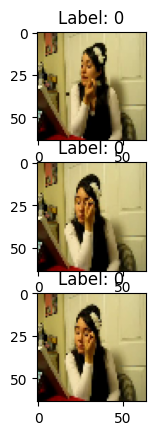

In [9]:
count = 0
fig, axs = plt.subplots(3)
while count < 3:
    img = imgs_total[60][count]
    axs[count].imshow(img)
    axs[count].set_title(f'Label: {labels_total[60]}')
    count += 1

- Train Test Split

In [10]:
x_train, x_test, y_train, y_test=train_test_split(imgs_total, labels_total, test_size=0.3, random_state=42)
x_train.shape, x_test.shape, np.array(y_train).shape, np.array(y_test).shape

((1885, 5, 64, 64, 3), (809, 5, 64, 64, 3), (1885,), (809,))

In [11]:
input_shape= (x_train.shape[1], x_train.shape[2], x_train.shape[3])
print(input_shape)

(5, 64, 64)


3. Build model C2D+LSTM

In [18]:
model = Sequential()

# Khối CNN 2D
model.add(Input((5, 64, 64, 3)))
model.add(Conv2D(32, (3, 3, 3), activation='relu'))
model.add(MaxPooling2D((1, 2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (1, 1, 1), activation='relu'))
model.add(MaxPooling2D((1, 2, 2)))
model.add(Dropout(0.25))

# Khối LSTM
model.add(TimeDistributed(Flatten()))
model.add(LSTM(128, return_sequences=True))
model.add(Dropout(0.25))

model.add(LSTM(64))
model.add(Dropout(0.25))

# Đầu ra
model.add(Dense(NUM_CLASSES, activation='softmax'))


model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d_7 (Conv3D)               │ (None, 3, 62, 62, 32)  │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_5 (MaxPooling3D)  │ (None, 3, 31, 31, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 3, 31, 31, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_8 (Conv3D)               │ (None, 3, 31, 31, 64)  │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_6 (MaxPooling3D)  │ (None, 3, 15, 15, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 3, 15, 15, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 3, 14400)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 3, 128)         │     7,438,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         1,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,494,292 (28.59 MB)

 Trainable params: 7,494,292 (28.59 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
#compile model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

- Training model CNN-LSTM

In [20]:
callbacks = [tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.1,min_lr=1e-6,patience=10,verbose=1),
             tf.keras.callbacks.EarlyStopping(monitor='val_loss',min_delta=0.0001,patience=30,verbose=1),
             tf.keras.callbacks.TensorBoard(log_dir='logs')]
results = model.fit(x_train, to_categorical(y_train), batch_size=32, epochs=75, validation_data=(x_test, to_categorical(y_test)),callbacks=callbacks)

Epoch 1/75
59/59 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.0913 - loss: 2.9397 - val_accuracy: 0.2806 - val_loss: 2.4747 - learning_rate: 0.0010
Epoch 2/75
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.3207 - loss: 2.2993 - val_accuracy: 0.4252 - val_loss: 1.8871 - learning_rate: 0.0010
Epoch 3/75
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.4729 - loss: 1.7941 - val_accuracy: 0.4808 - val_loss: 1.6325 - learning_rate: 0.0010
Epoch 4/75
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.5810 - loss: 1.4066 - val_accuracy: 0.6378 - val_loss: 1.2202 - learning_rate: 0.0010
Epoch 5/75
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.7420 - loss: 0.9180 - val_accuracy: 0.7429 - val_loss: 0.9304 - learning_rate: 0.0010
Epoch 6/75
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8065 - loss: 0.6749 - val_accuracy: 0.7824 - val_loss: 0.7733 - learning_rate: 0.0010
Epoch 7/75
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8998 - loss: 0.4110 - val_ac

- Plot the accuracy chart

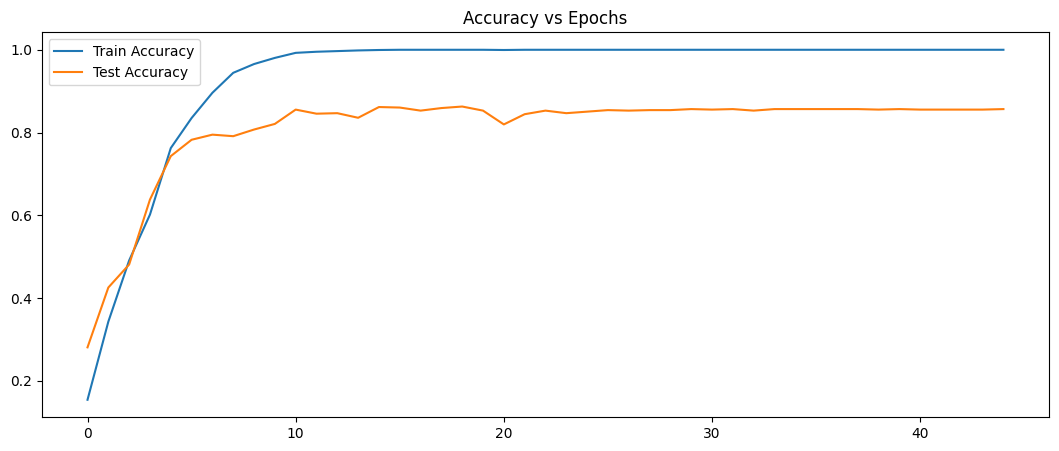

In [24]:
plt.figure(figsize=(13,5))
plt.title("Accuracy vs Epochs")
plt.plot(results.history['accuracy'], label='Train Accuracy')
plt.plot(results.history['val_accuracy'], label='Test Accuracy')
plt.legend(loc='best')
plt.show()

In [25]:
y_pred = model.predict(x_test)
predicted_classes=[]
for i in range(len(y_test)):
    predicted_classes.append(np.argmax(y_pred[i]))

accuracy_score(y_test, predicted_classes)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


0.8566131025957973

In [27]:
model.save_weights('/kaggle/working/CNNLSTM_model.weights.h5')

- Test model C2D-LSTM

In [28]:
def eval_real(folder_path):    
    imgs = []
    frames_generator = video_Frames(folder_path)
    frames_array = np.array(list(frames_generator))
    imgs.append(frames_array)
    real_imgs = np.array(imgs)

    pred1 = model.predict(real_imgs)
    pred1_max = pred1.argmax()
    label_lists = label_data['labels']
    label1 = label_lists[pred1_max]
    
    string = 'CNN-LSTM:',label1

    f,axs = plt.subplots(ncols = 1,nrows = 5)
    f.set_figwidth(20)
    f.set_figheight(20)
    for i in range(5):
        axs[i].imshow(real_imgs[0][i])
        axs[i].set_title(string)
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


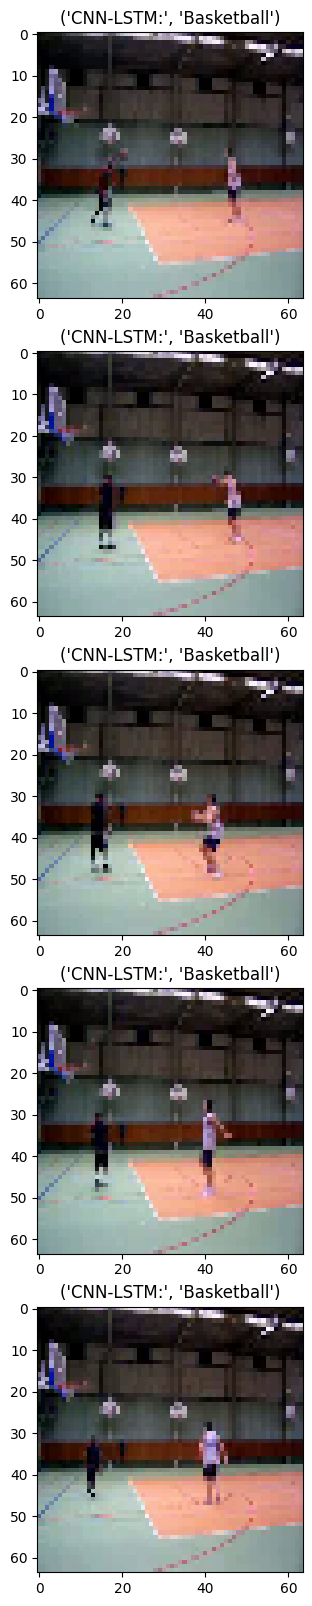

In [29]:
eval_real('/kaggle/input/ucf101/UCF101/UCF-101/Basketball/v_Basketball_g01_c02.avi')